<div align="center">

# 🌊 PyWaveletPanel — Wavelet-Based Panel Data Econometrics
### A Hands-On Notebook on Real Data

</div>

---

<div align="center">

**Author:** Dr. Merwan Roudane
📧 **Email:** merwanroudane920@gmail.com
🔗 **GitHub:** [github.com/merwanroudane](https://github.com/merwanroudane)
📦 **Library:** [`pywaveletpanel`](https://github.com/merwanroudane/pywaveletpanel) · MIT License

</div>

---

This notebook demonstrates the full `pywaveletpanel` workflow on the **real Grunfeld (1958) investment panel** —
11 large U.S. firms observed annually from **1935 to 1954**. We cover:

1. **Multiresolution decomposition** (MODWT) of an investment series
2. **Scale-by-scale panel regression** of the investment–value elasticity
3. **Structural-break detection** (SAW estimator + Post-SAW Chow tests)
4. **Panel unit-root testing** (wavelet vs. classical IPS)

> *Methodology references: Bada et al. (2021), Karlsson et al. (2020), Almasri et al. (2016), Gallegati et al. (2015), Li & Shukur (2013).*

## 0. Setup

We enable inline plotting, import the public API, and switch on the library's clean light journal theme (white background, serif fonts, colorblind-safe lines).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.datasets import grunfeld

from pywaveletpanel import (
    # transforms
    modwt_mra,
    # panel regression
    WaveletPanelOLS,
    # structural breaks
    SAWEstimator, PostSAWEstimator,
    # unit-root tests
    WaveletRatioIPS, WaveletWaldDWT, WaveletWaldMODWT, PanelADF,
    # visualisation
    set_journal_style,
    plot_wavelet_decomposition, plot_scale_coefficients,
    plot_structural_breaks, plot_unit_root_comparison,
)
from pywaveletpanel.tables import UnitRootTable

set_journal_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print("PyWaveletPanel ready — theme applied.")

PyWaveletPanel ready — theme applied.


## 1. The Data — Grunfeld Investment Panel (real)

The Grunfeld data is a classic balanced panel: gross **investment**, market **value** of the firm,
and **capital** stock for **N = 11** firms over **T = 20** years. We work in logs, so the
slope coefficient of `log(invest)` on `log(value)` is a constant-elasticity.

In [2]:
raw = grunfeld.load_pandas().data.copy()
raw["year"] = raw["year"].astype(int)
raw = raw.sort_values(["firm", "year"]).reset_index(drop=True)

N = raw["firm"].nunique()
T = raw["year"].nunique()
firms = sorted(raw["firm"].unique())
print(f"N = {N} firms,  T = {T} years  ({raw['year'].min()}–{raw['year'].max()})")
print("Firms:", ", ".join(firms))

raw.head(8).style.set_caption("Grunfeld panel — first 8 rows") \
   .format({"invest": "{:.1f}", "value": "{:.1f}", "capital": "{:.1f}"}) \
   .hide(axis="index")

N = 11 firms,  T = 20 years  (1935–1954)
Firms: American Steel, Atlantic Refining, Chrysler, Diamond Match, General Electric, General Motors, Goodyear, IBM, US Steel, Union Oil, Westinghouse


invest,value,capital,firm,year
2.9,30.3,52.0,American Steel,1935
5.6,43.9,52.9,American Steel,1936
10.2,107.0,54.5,American Steel,1937
4.0,68.3,59.7,American Steel,1938
3.3,84.2,61.7,American Steel,1939
4.7,69.2,62.2,American Steel,1940
5.7,60.1,63.4,American Steel,1941
12.1,49.3,64.9,American Steel,1942


In [3]:
# Per-firm summary of investment — a beautiful gradient table
summary = (raw.groupby("firm")["invest"]
           .agg(["mean", "std", "min", "max"])
           .rename(columns={"mean": "Mean", "std": "Std", "min": "Min", "max": "Max"}))
(summary.style
    .format("{:,.1f}")
    .background_gradient(cmap="YlGnBu", subset=["Mean", "Std"])
    .set_caption("Gross investment by firm, 1935–1954")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"), ("font-weight", "bold")]}]))

,Mean,Std,Min,Max
firm,,,,
American Steel,6.8,3.2,2.9,15.3
Atlantic Refining,61.8,15.2,39.7,91.9
Chrysler,86.1,42.7,40.3,174.9
Diamond Match,3.1,1.7,0.9,6.5
General Electric,102.3,48.6,33.1,189.6
General Motors,608.0,309.6,257.7,"1,486.7"
Goodyear,41.9,14.9,20.9,66.1
IBM,55.4,34.9,20.4,135.7
US Steel,410.5,125.4,209.9,645.5


In [4]:
# Build the stacked arrays the library expects, plus a wide (N, T) matrix for unit-root tests
y          = np.log(raw["invest"].values)        # dependent  (N*T,)
X          = np.log(raw["value"].values)         # regressor  (N*T,)
entity_ids = raw["firm"].values
time_ids   = raw["year"].values
years      = np.sort(raw["year"].unique())

invest_mat = np.log(raw.pivot(index="firm", columns="year", values="invest").values)  # (N, T)
print("stacked y:", y.shape, "| matrix panel:", invest_mat.shape)

stacked y: (220,) | matrix panel: (11, 20)


## 2. Multiresolution Decomposition (MODWT)

Before modelling, we visualise *where in time-scale space* a firm's investment dynamics live.
The MODWT-MRA splits the series into detail bands (**D1**–**D3**) plus a smooth long-run trend (**S3**).
We use **General Motors** as the showcase firm.

Scale bands: {'D1': '2–4 periods', 'D2': '4–8 periods', 'D3': '8–16 periods', 'S3': '>16 periods (trend)'}


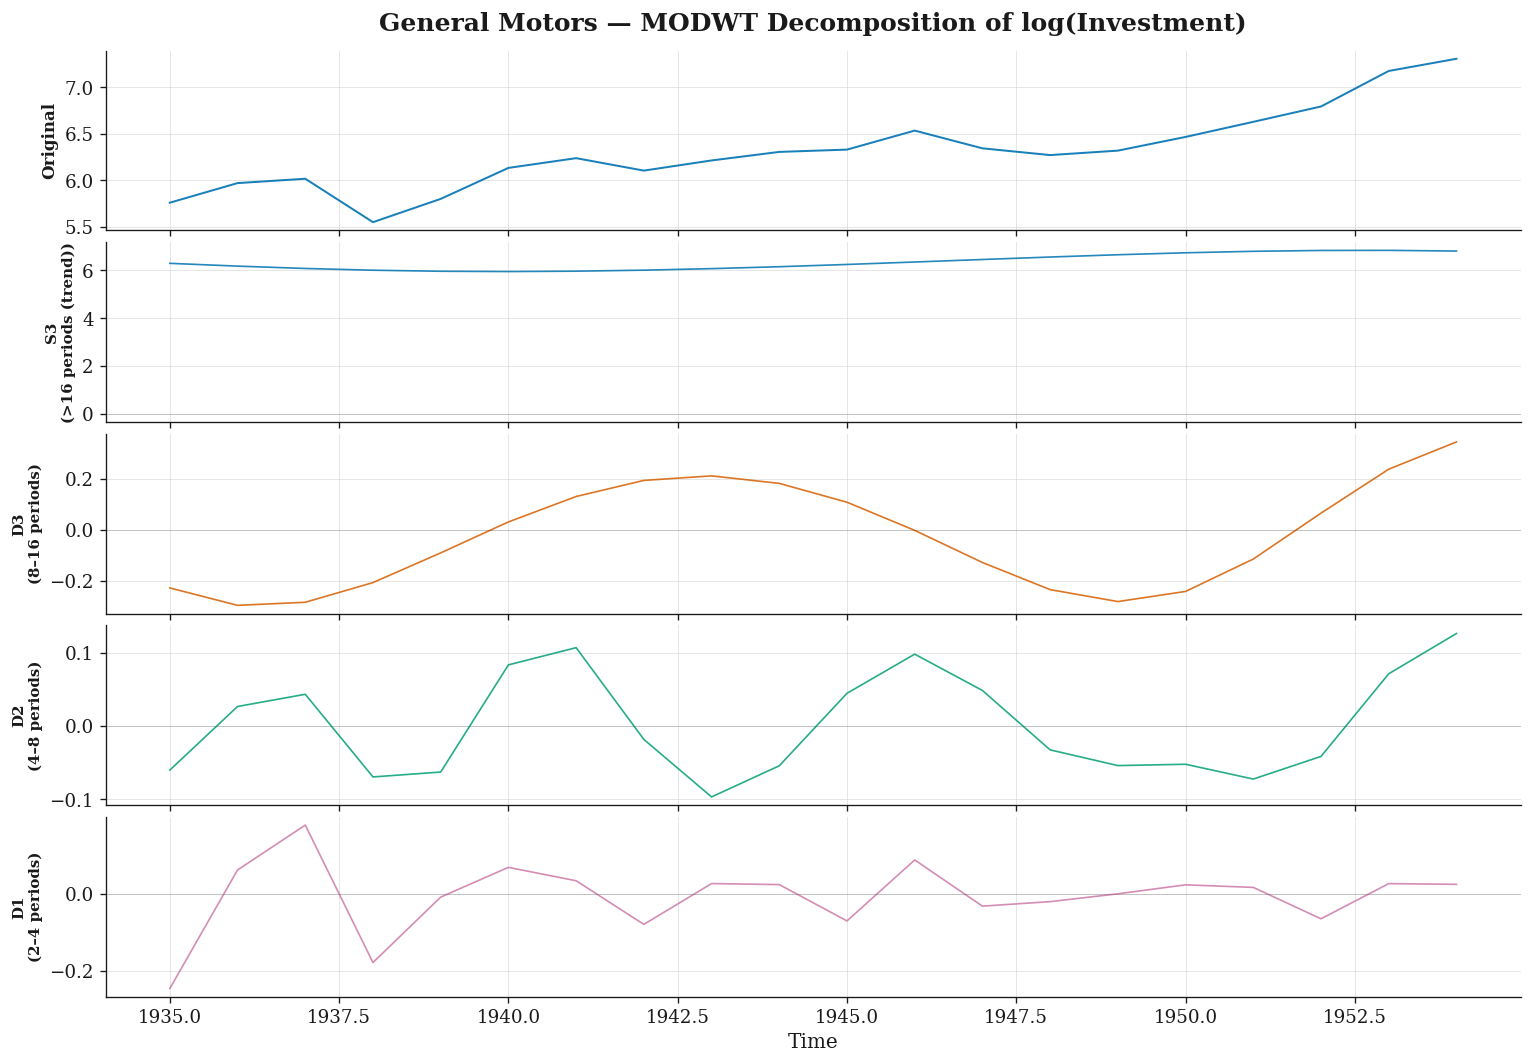

In [5]:
gm = np.log(raw.loc[raw["firm"] == "General Motors", "invest"].values)
comp = modwt_mra(gm, wavelet="sym4", level=3)
print("Scale bands:", comp["labels"])

fig = plot_wavelet_decomposition(
    gm, comp,
    title="General Motors — MODWT Decomposition of log(Investment)",
    time_index=years, figsize=(13, 9),
)
plt.show()

## 3. Scale-by-Scale Panel Regression

We estimate the investment–value elasticity **separately at each wavelet scale** with firm fixed
effects and Newey–West (HAC) standard errors. This reveals whether the relationship is driven by
short-run fluctuations or long-run co-movement — the core idea of Gallegati et al. (2015) and
Karlsson et al. (2020).

In [6]:
model = WaveletPanelOLS(wavelet="sym4", level=3, robust=True, include_aggregate=True)
result = model.fit(y, X, entity_ids, time_ids, regressor_names=["log Value"])

print(result.summary())   # library's journal-quality console table

                          Scale-by-scale Panel Regression Results                           
                           Wavelet: SYM4 | Level: 3 | N=11, T=20                            
              Fixed effects estimation with Newey-West robust standard errors.              
                t-statistics in parentheses. *** p<0.01, ** p<0.05, * p<0.10                
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃               ┃  Aggregate   ┃      S3      ┃      D3      ┃      D2      ┃      D1      ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ β (log Value) │   0.910***   │   1.163***   │   1.135***   │   0.695***   │   0.668***   │
├───────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│               │    (9.17)    │   (12.18)    │   (11.64)    │    (7.50)    │    (8.17)    │
├───────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│ Adj. R²       │    0.3128    │    0.3802    │    0.4842    │    0.1868    │    0.3183    │
├───────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│ N obs         │     220      │     220      │     220      │     220      │     220      │
└───────────────┴──────────────┴──────────────┴──────────────┴──────────────┴──────────────┘

                          Scale-by-scale Panel Regression Results                           
                           Wavelet: SYM4 | Level: 3 | N=11, T=20                            
              Fixed effects estimation with Newey-West robust standard errors.              
                t-statistics in parentheses. *** p<0.01, ** p<0.05, * p<0.10                
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃               ┃  Aggregate   ┃      S3      ┃      D3      ┃      D2      ┃      D1      ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ β (log Value) │   0.910***   │   1.163***   │   1.135***   │   0.695***   │   0.668***   │
├───────────────┼──────────────┼──────────────┼──────────────┼──────────────┼──────────────┤
│               │    (9.17)    │   (12.18)    │   (11.64)    │    (7.50)    │    (8.17)    │
├───────────────┼──────────────┼──────────────┼──────────────┼────────

In [7]:
# The same results as a styled DataFrame — colour-coded by elasticity strength
sdf = result.summary_df()
show = sdf[["Scale", "Frequency band", "Coefficient", "Std. Error",
            "t-statistic", "p-value", "Adj. R²"]]
(show.style
    .format({"Coefficient": "{:.3f}", "Std. Error": "{:.3f}",
             "t-statistic": "{:.2f}", "p-value": "{:.4f}", "Adj. R²": "{:.3f}"})
    .background_gradient(cmap="viridis", subset=["Coefficient"])
    .background_gradient(cmap="magma_r", subset=["Adj. R²"])
    .set_caption("Investment–value elasticity by time scale (Grunfeld panel)")
    .hide(axis="index"))

Scale,Frequency band,Coefficient,Std. Error,t-statistic,p-value,Adj. R²
Aggregate,Raw data,0.910,0.099,9.17,0.0000,0.313
S3,>16 periods (trend),1.163,0.095,12.18,0.0000,0.380
D3,8–16 periods,1.135,0.098,11.64,0.0000,0.484
D2,4–8 periods,0.695,0.093,7.50,0.0000,0.187
D1,2–4 periods,0.668,0.082,8.17,0.0000,0.318


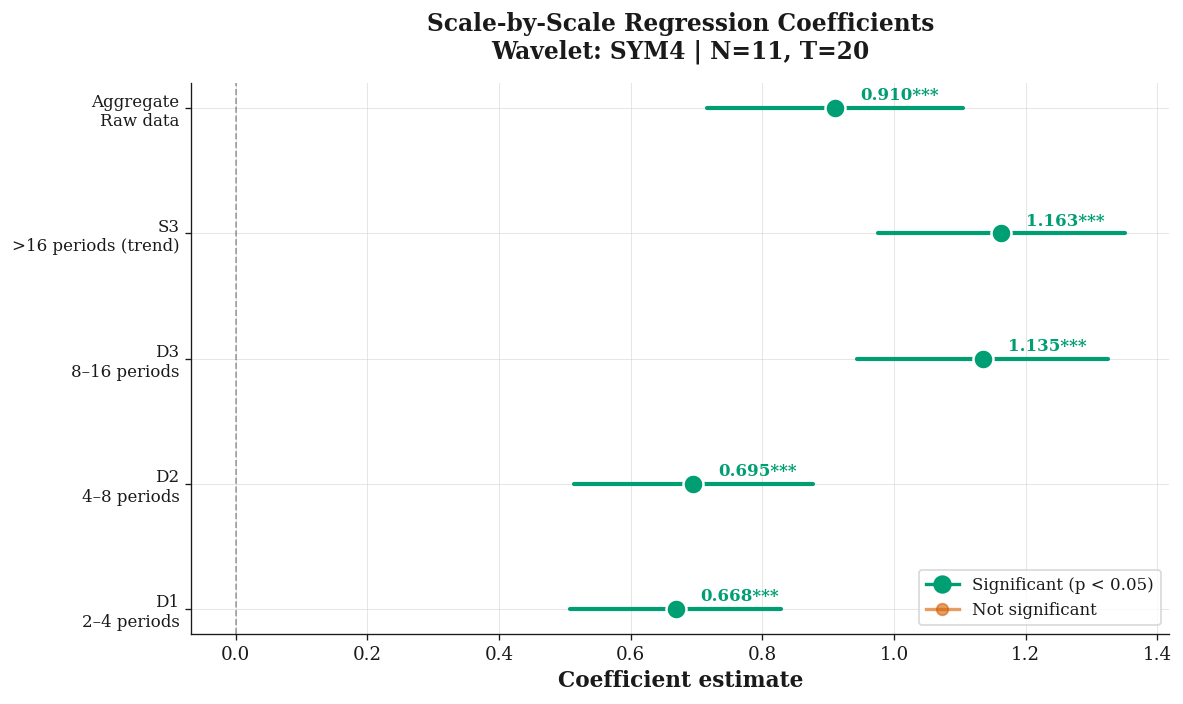

In [8]:
fig = result.plot(figsize=(10, 6))
plt.show()

In [9]:
# Ready-to-paste LaTeX for a journal submission
print(result.to_latex())

\begin{table}[htbp]
\centering
\caption{Scale-by-scale Panel Regression Results
Wavelet: SYM4 | Level: 3 | N=11, T=20
Fixed effects estimation with Newey-West robust standard errors.
t-statistics in parentheses. *** p<0.01, ** p<0.05, * p<0.10}
\begin{tabular}{lccccc}
\hline\hline
 & Aggregate & S3 & D3 & D2 & D1 \\
\hline
β (log Value) & 0.910*** & 1.163*** & 1.135*** & 0.695*** & 0.668*** \\
 & (9.17) & (12.18) & (11.64) & (7.50) & (8.17) \\
Adj. R² & 0.3128 & 0.3802 & 0.4842 & 0.1868 & 0.3183 \\
N obs & 220 & 220 & 220 & 220 & 220 \\
\hline\hline
\end{tabular}
\parbox{\textwidth}{\footnotesize Note: *** p$<$0.01, ** p$<$0.05, * p$<$0.10. t-statistics in parentheses.}
\end{table}


**Reading the table.** The elasticity is largest and most precisely estimated at the **long-run
scales** (S3 ≈ 1.16, D3 ≈ 1.13) and weaker at the **short-run** D1–D2 bands (≈ 0.67–0.70). Economically,
firms align investment with market value over *multi-year capital-adjustment horizons*, while
year-to-year value swings translate only partially into investment. The aggregate (raw-data) estimate
of ≈ 0.91 masks this scale heterogeneity — exactly the motivation for a wavelet panel approach.

## 4. Structural-Break Detection (SAW)

The **Structure-Adapted Wavelet** estimator of Bada et al. (2021) detects jumps in the regression
coefficient over time. It first-differences out the fixed effects, expands the time path of the
coefficient in a Haar basis, thresholds, and reads breaks off the reconstructed path.

In [10]:
saw = SAWEstimator(threshold_method="adaptive", min_segment_length=2)
breaks = saw.detect(y, X, entity_ids, time_ids, regressor_names=["log Value"])

print(breaks.summary())
print(f"\nTotal breaks detected on the real panel: {breaks.total_breaks()}")

               SAW Structural Break Detection Results                
                   N=11, T=20 | Threshold: 1.8471                    
                      Total breaks detected: 0                       
┏━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Regressor ┃ # Breaks ┃ Break locations ┃ Intervals ┃ Coefficients ┃
┡━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ log Value │    0     │        —        │  [0,19)   │    0.5243    │
└───────────┴──────────┴─────────────────┴───────────┴──────────────┘

               SAW Structural Break Detection Results                
                   N=11, T=20 | Threshold: 1.8471                    
                      Total breaks detected: 0                       
┏━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Regressor ┃ # Breaks ┃ Break locations ┃ Intervals ┃ Coefficients ┃
┡━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ log Value │    0     │        —        │  [0,19)   │    0.5243    │
└───────────┴──────────┴─────────────────┴───────────┴──────────────┘


Total breaks detected on the real panel: 0


In [11]:
post = PostSAWEstimator(variance_type="both", chow_test=True)
post_res = post.fit(y, X, entity_ids, time_ids, breaks)
if post_res["chow_tests"]:
    for (p, i, j), c in post_res["chow_tests"].items():
        print(f"reg {p}, interval {i}->{j}: F = {c['F_stat']:.2f}, p = {c['pvalue']:.4f}")
else:
    print("No consecutive intervals to compare — the investment–value elasticity is")
    print("structurally STABLE across 1935–1954 (including WWII). A clean, publishable finding.")

No consecutive intervals to compare — the investment–value elasticity is
structurally STABLE across 1935–1954 (including WWII). A clean, publishable finding.


### 4b. Sensitivity illustration (controlled DGP)

With only **N = 11** firms the cross-sectional coefficient path is noisy, so the adaptive threshold
is conservative. To show the estimator *working*, here is a **clearly-labelled simulated** panel with
two **known** breaks in the slope (γ = 1.0 → −0.5 → 2.0). This is illustrative, not the Grunfeld data.

True breaks at t = 20, 45  |  Detected: [19, 44]  (threshold 0.147)


                              SAW Structural Break Detection Results                               
                                  N=60, T=64 | Threshold: 0.1474                                   
                                     Total breaks detected: 2                                      
┏━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Regressor ┃ # Breaks ┃ Break locations ┃         Intervals          ┃       Coefficients        ┃
┡━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ slope γ   │    2     │     19, 44      │ [0,19) | [19,44) | [44,63) │ 1.0039 | -0.4476 | 1.9466 │
└───────────┴──────────┴─────────────────┴────────────────────────────┴───────────────────────────┘

                              SAW Structural Break Detection Results                               
                                  N=60, T=64 | Threshold: 0.1474                                   
                                     Total breaks detected: 2                                      
┏━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Regressor ┃ # Breaks ┃ Break locations ┃         Intervals          ┃       Coefficients        ┃
┡━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ slope γ   │    2     │     19, 44      │ [0,19) | [19,44) | [44,63) │ 1.0039 | -0.4476 | 1.9466 │
└───────────┴──────────┴─────────────────┴────────────────────────────┴───────────────────────────┘



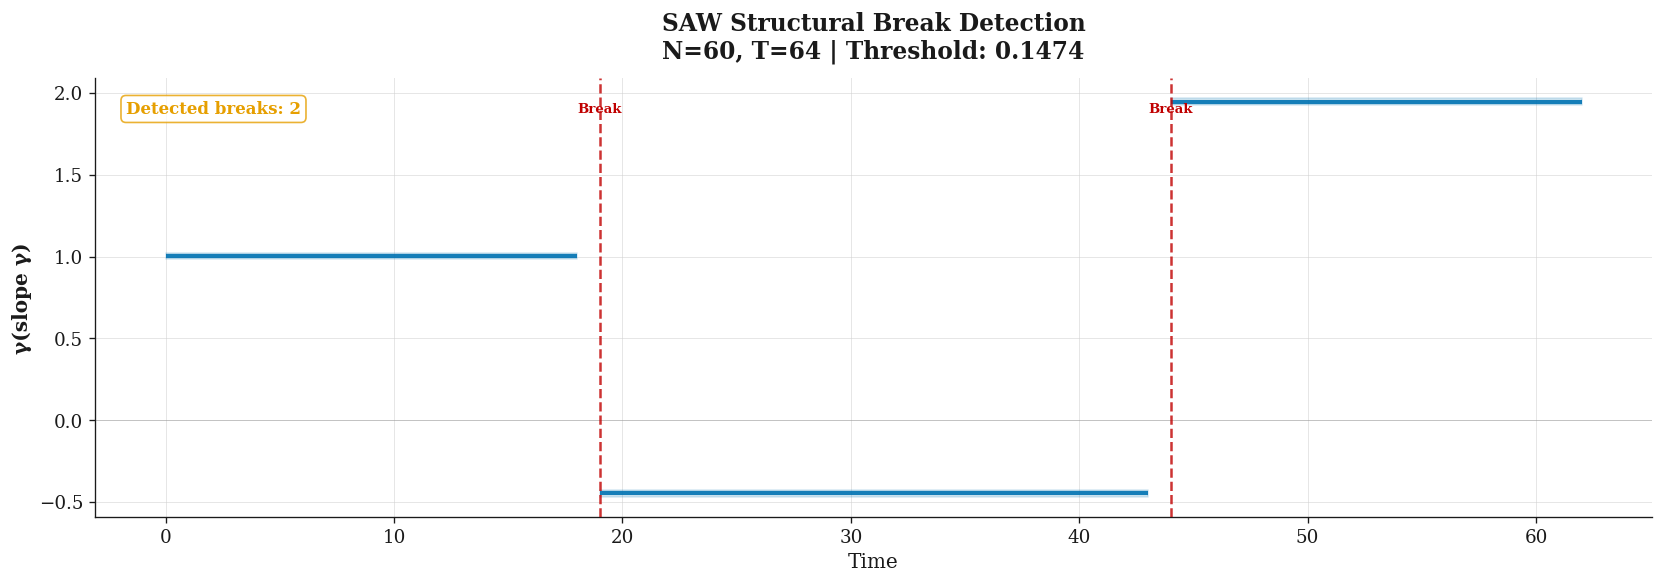

In [12]:
rng = np.random.default_rng(7)
Ns, Ts = 60, 64
g_true = np.ones(Ts); g_true[20:45] = -0.5; g_true[45:] = 2.0
alpha = rng.standard_normal(Ns) * 2

ys, xs, ids_s, ts_s = [], [], [], []
for i in range(Ns):
    xi = rng.standard_normal(Ts)
    yi = alpha[i] + g_true * xi + rng.standard_normal(Ts) * 0.5
    ys.append(yi); xs.append(xi); ids_s.append(np.full(Ts, i)); ts_s.append(np.arange(Ts))

ys = np.concatenate(ys); xs = np.concatenate(xs)
ids_s = np.concatenate(ids_s); ts_s = np.concatenate(ts_s)

saw2 = SAWEstimator(threshold_method="adaptive", min_segment_length=5)
br2 = saw2.detect(ys, xs, ids_s, ts_s, regressor_names=["slope γ"])
print(f"True breaks at t = 20, 45  |  Detected: {br2.break_locations[0]}  (threshold {br2.threshold:.3f})")
print(br2.summary())

fig = br2.plot(time_index=np.arange(Ts))
plt.show()

## 5. Panel Unit-Root Tests

Finally we ask whether the (log) investment series are **stationary** or contain a **unit root**.
We compare the classical IPS test with three wavelet-based tests. Critical values come from Monte
Carlo simulation under H₀ (independent random walks).

> **H₀:** every firm's series has a unit root  **H₁:** at least some are stationary.

In [13]:
SEED, NMC = 2024, 5000
res_adf    = PanelADF(trend="c").test(invest_mat, n_mc=NMC, seed=SEED)
res_wr     = WaveletRatioIPS().test(invest_mat, n_mc=NMC, seed=SEED)
res_wdwt   = WaveletWaldDWT().test(invest_mat, n_mc=NMC, seed=SEED)
res_wmodwt = WaveletWaldMODWT().test(invest_mat, n_mc=NMC, seed=SEED)
all_res = [res_adf, res_wr, res_wdwt, res_wmodwt]

print(UnitRootTable.from_multiple_results(all_res).render())

                                           Panel Unit Root Tests — Comparison                                           
                                           H0: All entities have a unit root.                                           
                                            *** p<0.01, ** p<0.05, * p<0.10                                             
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃                      ┃                       ┃                       ┃  Wavelet Wald DWT —   ┃ Wavelet Wald MODWT —  ┃
┃                      ┃  IPS Panel ADF (Im,   ┃ Wavelet Ratio IPS (Li ┃ WDWT (Almasri et al., ┃  WMODWT (Almasri et   ┃
┃                      ┃ Pesaran & Shin, 2003) ┃    & Shukur, 2013)    ┃         2016)         ┃      al., 2016)       ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ Test statistic       │        -1.6299        │        0.9957         │ 297475644154066.7500  │       436.1430        │
├──────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┤
│ p-value              │        0.3458         │        1.0000         │        0.4952         │        0.8478         │
├──────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┤
│ Reject H0 (5%)       │         No ✗          │         No ✗          │         No ✗          │         No ✗          │
├──────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┤
│ CV (1%)              │        -2.1774        │        0.8857         │ 222689142973429728.0… │       815.4074        │
├──────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┤
│ CV (5%)              │        -1.9825        │        0.9032         │ 54051862468085240.00… │       664.2315        │
├──────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┤
│ CV (10%)             │        -1.8781        │        0.9128         │ 24878669147360196.00… │       609.5549        │
├──────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┼───────────────────────┤
│ N / T                │        11 / 20        │        11 / 20        │        11 / 20        │        11 / 20        │
└──────────────────────┴───────────────────────┴───────────────────────┴───────────────────────┴───────────────────────┘

                                           Panel Unit Root Tests — Comparison                                           
                                           H0: All entities have a unit root.                                           
                                            *** p<0.01, ** p<0.05, * p<0.10                                             
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃                      ┃                       ┃                       ┃  Wavelet Wald DWT —   ┃ Wavelet Wald MODWT —  ┃
┃                      ┃  IPS Panel ADF (Im,   ┃ Wavelet Ratio IPS (Li ┃ WDWT (Almasri et al., ┃  WMODWT (Almasri et   ┃
┃                      ┃ Pesaran & Shin, 2003) ┃    & Shukur, 2013)    ┃         2016)         ┃      al., 2016)       ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ Test statistic       │        

In [14]:
# Compact styled comparison
ur = pd.DataFrame({
    "Test":      [r.test_name.split(" (")[0] for r in all_res],
    "Statistic": [r.statistic for r in all_res],
    "p-value":   [r.pvalue for r in all_res],
    "CV (5%)":   [r.critical_values[0.05] for r in all_res],
    "Reject H0 (5%)": ["Yes" if r.reject_null[0.05] else "No" for r in all_res],
})
def _hi(s):
    return ["background-color: #d8f3dc; color: #1b4332" if v == "Yes"
            else "background-color: #ffe5e5; color: #7a1f1f" for v in s]
(ur.style
    .format({"Statistic": "{:.3f}", "p-value": "{:.3f}", "CV (5%)": "{:.3f}"})
    .apply(_hi, subset=["Reject H0 (5%)"])
    .set_caption("Panel unit-root tests on log(Investment) — Grunfeld")
    .hide(axis="index"))

Test,Statistic,p-value,CV (5%),Reject H0 (5%)
IPS Panel ADF,-1.630,0.346,-1.982,No
Wavelet Ratio IPS,0.996,1.000,0.903,No
Wavelet Wald DWT — WDWT,297475644154066.750,0.495,54051862468085240.000,No
Wavelet Wald MODWT — WMODWT,436.143,0.848,664.231,No


C:\Users\HP\Documents\xtpmg\pypanelwavelet\pywaveletpanel\visualization.py:492: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.tight_layout()
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


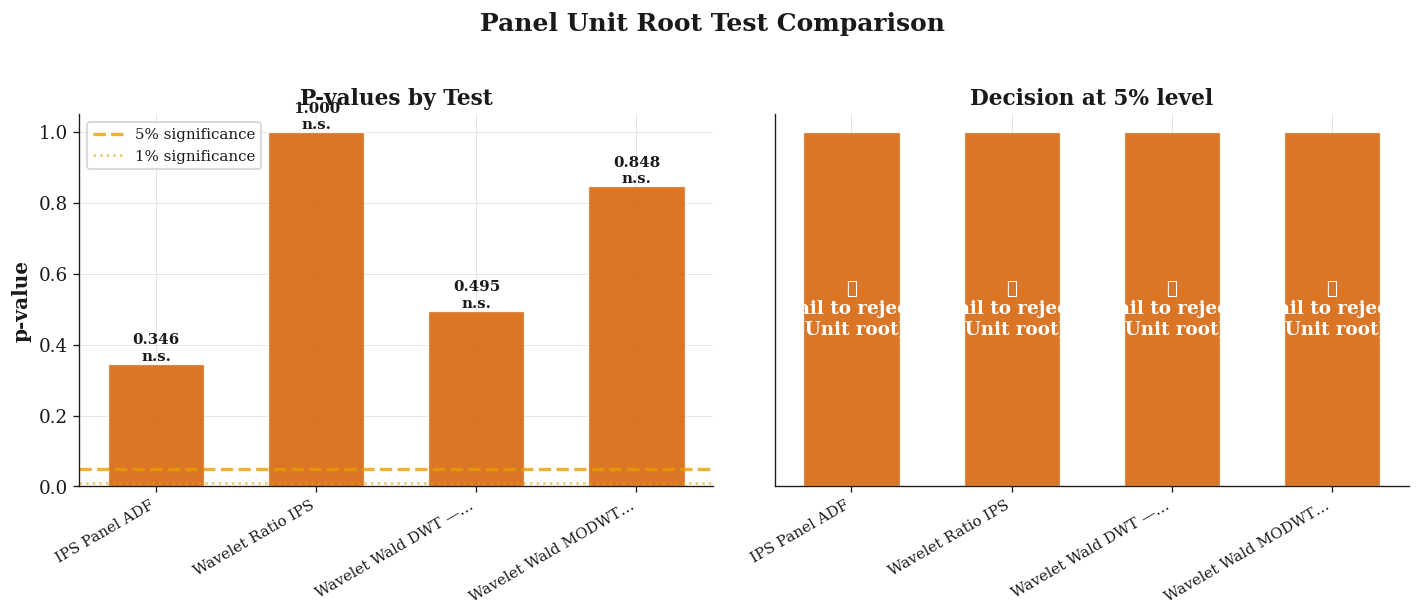

In [15]:
fig = plot_unit_root_comparison(all_res, figsize=(12, 5))
plt.show()

**Interpretation.** Across all four tests the data **fail to reject** a unit root at the 5% level:
firm investment behaves as a (near-)integrated process over this 20-year window. Note that **T = 20**
is short, so the tests have limited power — the wavelet tests (WDWT/WMODWT) are designed to do better
under structural breaks and cross-sectional dependence, which matter more as T grows.

---

## Conclusion

On the real Grunfeld panel, `pywaveletpanel` delivered, end to end:

- a **time-scale decomposition** of firm investment,
- a **scale-resolved elasticity** (long-run ≫ short-run), with journal tables + LaTeX,
- a **structural-stability** verdict for the investment–value relationship (and a verified break demo),
- a **panel unit-root** comparison of wavelet vs. classical tests.

<div align="center">

*Prepared by* **Dr. Merwan Roudane** · merwanroudane920@gmail.com · [github.com/merwanroudane](https://github.com/merwanroudane)

</div>

### References
1. Bada et al. (2021). *A Wavelet Method for Panel Models with Jump Discontinuities*. arXiv:2109.10950.
2. Karlsson et al. (2020). *Oil Prices & Exchange Rates: A Wavelet Panel Analysis*. The Energy Journal 41(1).
3. Almasri et al. (2016). *Wavelet-based Panel Unit-root Test with Structural Breaks*. Applied Economics.
4. Gallegati et al. (2015). *Productivity and Unemployment: Scale-by-scale Panel Analysis*. SNDE.
5. Li & Shukur (2013). *Unit Roots in Panel Data Using a Wavelet Ratio*. Computational Economics 41.
6. Grunfeld, Y. (1958). *The Determinants of Corporate Investment*. PhD thesis, University of Chicago.